# Project UAS Data Mining  
## Forecasting Jumlah Penyewaan Sepeda Menggunakan Bike Sharing Dataset

### Identitas Mahasiswa
- Nama: Siti Wahyu Nur Asiah Jamil
- Kelas: SI 24 P SIM 2
- Mata Kuliah: Konsep Data Warehouse & Mining
- Kategori Studi Kasus: Forecasting / Peramalan

### Sumber Dataset
Bike Sharing Dataset  
https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset

Dataset yang digunakan adalah file `hour.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# 1. Business Understanding

## 1.1 Latar Belakang

Bike Sharing merupakan layanan penyewaan sepeda yang dapat digunakan sebagai alternatif transportasi maupun rekreasi. Jumlah penyewaan sepeda dapat berubah-ubah dipengaruhi oleh berbagai faktor, seperti waktu, musim, hari kerja, hari libur, cuaca, suhu, kelembapan, dan kecepatan angin.

Perubahan jumlah penyewaan yang tidak stabil dapat menyulitkan pengelola dalam menentukan jumlah sepeda yang harus tersedia. Oleh karena itu, diperlukan analisis forecasting untuk memprediksi jumlah penyewaan sepeda berdasarkan data historis.

## 1.2 Tujuan Project

Tujuan dari project ini adalah membangun model forecasting untuk memprediksi jumlah penyewaan sepeda berdasarkan faktor waktu, kondisi cuaca, dan karakteristik hari tertentu.

## 1.3 Manfaat Analisis

Manfaat dari analisis ini adalah membantu pengelola layanan Bike Sharing dalam memperkirakan jumlah permintaan, mengatur ketersediaan sepeda, serta mendukung pengambilan keputusan operasional berbasis data.

# 2. Data Understanding

## 2.1 Deskripsi Dataset

Dataset yang digunakan adalah Bike Sharing Dataset yang diperoleh dari Kaggle. Dataset ini berisi data penyewaan sepeda berdasarkan jam dengan total 17.379 data dan 17 atribut.

Target yang digunakan dalam project ini adalah kolom `cnt`, yaitu total jumlah penyewaan sepeda.

Beberapa atribut penting dalam dataset ini antara lain:
- `season`: musim
- `yr`: tahun
- `mnth`: bulan
- `hr`: jam
- `holiday`: status hari libur
- `weekday`: hari dalam minggu
- `workingday`: status hari kerja
- `weathersit`: kondisi cuaca
- `temp`: suhu
- `atemp`: suhu yang dirasakan
- `hum`: kelembapan
- `windspeed`: kecepatan angin
- `cnt`: total jumlah penyewaan sepeda

In [2]:
df = pd.read_csv("hour.csv")

print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2.2 Struktur Dataset

Tahap ini dilakukan untuk mengetahui struktur dataset, jumlah data, jumlah atribut, tipe data, serta apakah terdapat nilai kosong pada setiap kolom.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## 2.3 Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat ringkasan nilai numerik pada dataset, seperti nilai rata-rata, standar deviasi, nilai minimum, dan nilai maksimum.

In [4]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## 2.4 Pemeriksaan Missing Value dan Duplikasi Data

Pemeriksaan missing value dilakukan untuk memastikan tidak terdapat data kosong yang dapat memengaruhi proses analisis. Selain itu, pemeriksaan duplikasi dilakukan untuk memastikan tidak terdapat data yang tercatat berulang.

In [5]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


## 2.5 Eksplorasi Data Awal

Eksplorasi data awal dilakukan untuk memahami pola penyewaan sepeda berdasarkan beberapa faktor, seperti distribusi jumlah penyewaan, jam, musim, cuaca, dan hubungan antar variabel.

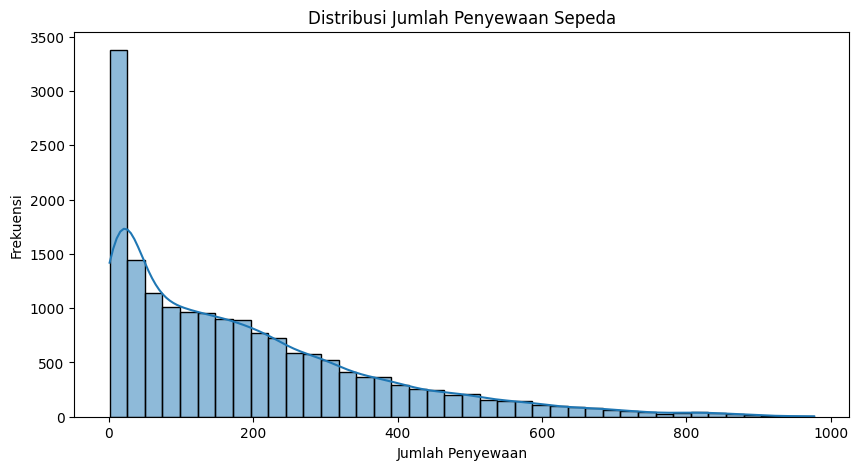

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df["cnt"], bins=40, kde=True)
plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

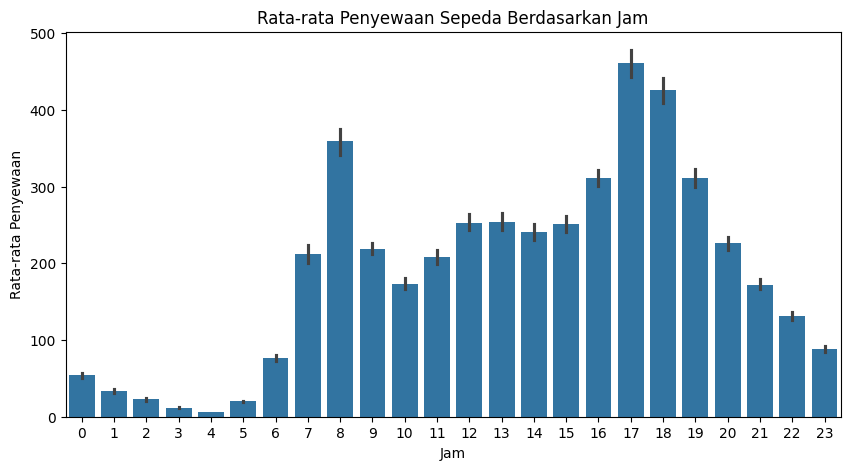

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="hr", y="cnt", estimator=np.mean)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

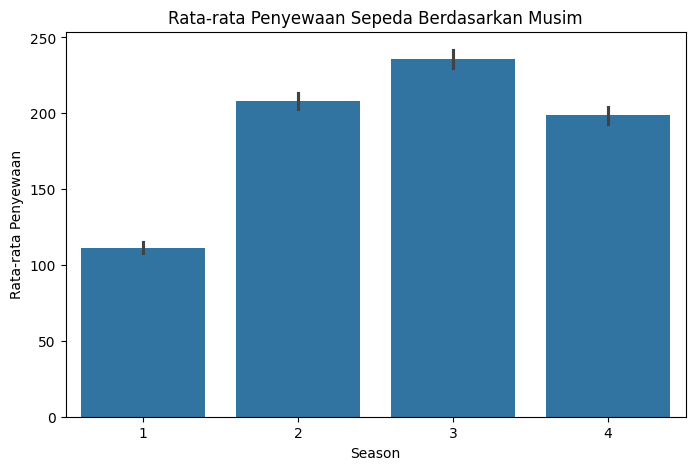

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="season", y="cnt", estimator=np.mean)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Season")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

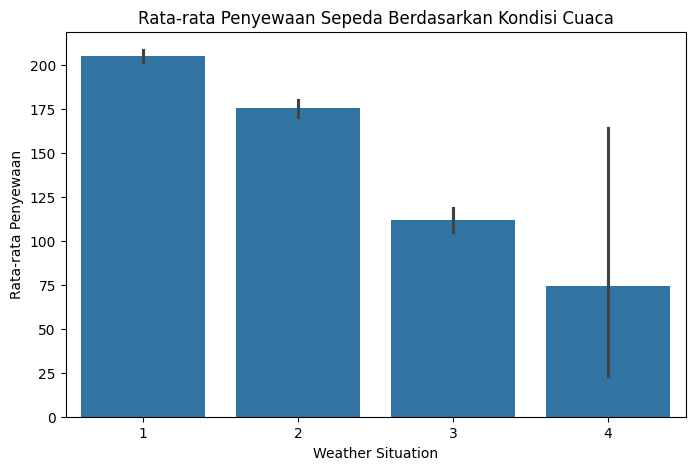

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="weathersit", y="cnt", estimator=np.mean)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.xlabel("Weather Situation")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

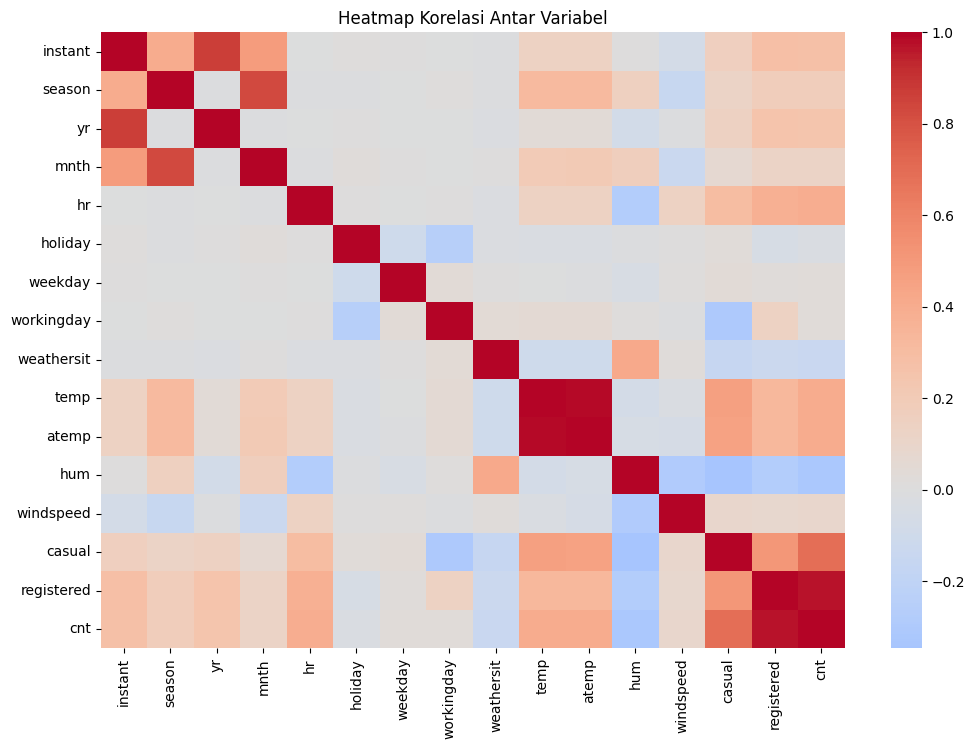

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

In [12]:
corr["cnt"].sort_values(ascending=False)

cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
instant       0.278379
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64

## 2.6 Kesimpulan Data Understanding

Berdasarkan hasil Data Understanding, dataset Bike Sharing memiliki 17.379 data dan 17 atribut sehingga telah memenuhi ketentuan minimal 5.000 data. Dataset tidak memiliki missing value dan tidak terdapat data duplikat. Variabel target yang digunakan adalah `cnt`, yaitu total jumlah penyewaan sepeda. Hasil eksplorasi awal menunjukkan bahwa jumlah penyewaan sepeda dipengaruhi oleh beberapa faktor seperti jam, suhu, musim, kondisi cuaca, kelembapan, dan status hari kerja.

# 3. Data Preparation

## 3.1 Data Cleaning

Data cleaning dilakukan untuk memastikan dataset siap digunakan pada tahap modeling. Berdasarkan hasil pemeriksaan, dataset tidak memiliki data duplikat. Namun, proses penghapusan duplikasi tetap dilakukan untuk memastikan data yang digunakan benar-benar bersih.

## 3.2 Handling Missing Values

Berdasarkan hasil pengecekan, dataset tidak memiliki missing value pada seluruh atribut. Oleh karena itu, tidak diperlukan proses imputasi atau penghapusan data kosong.

## 3.3 Encoding Data

Seluruh fitur yang digunakan dalam proses modeling telah berbentuk numerik. Oleh karena itu, tidak diperlukan proses encoding tambahan.

## 3.4 Normalisasi atau Transformasi Data

Normalisasi tidak dilakukan karena model utama yang digunakan adalah Random Forest Regressor. Algoritma Random Forest tidak sensitif terhadap perbedaan skala antar fitur sehingga proses normalisasi tidak diperlukan.

## 3.5 Seleksi Fitur

Kolom `instant` dihapus karena hanya berfungsi sebagai ID. Kolom `dteday` tidak digunakan secara langsung karena informasi waktu sudah tersedia pada atribut `yr`, `mnth`, dan `hr`.

Kolom `casual` dan `registered` juga dihapus karena keduanya merupakan bagian penyusun target `cnt`. Jika digunakan, model dapat mengalami data leakage karena `cnt = casual + registered`.

## 3.6 Pembagian Data Training dan Testing

Dataset dibagi menjadi data training sebesar 80% dan data testing sebesar 20%. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model.

In [13]:
df_clean = df.drop_duplicates()

print("Jumlah data sebelum cleaning:", df.shape)
print("Jumlah data setelah cleaning:", df_clean.shape)

Jumlah data sebelum cleaning: (17379, 17)
Jumlah data setelah cleaning: (17379, 17)


In [14]:
model_df = df_clean.drop(
    columns=["instant", "dteday", "casual", "registered"]
)

model_df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [15]:
print("Jumlah baris dan kolom setelah seleksi fitur:", model_df.shape)
model_df.columns.tolist()

Jumlah baris dan kolom setelah seleksi fitur: (17379, 13)


['season',
 'yr',
 'mnth',
 'hr',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'cnt']

In [16]:
X = model_df.drop(columns=["cnt"])
y = model_df["cnt"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah target:", len(y))

Jumlah fitur: 12
Jumlah target: 17379


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (13903, 12)
Data testing: (3476, 12)


## 3.7 Kesimpulan Data Preparation

Tahap Data Preparation telah dilakukan dengan membersihkan data, memeriksa missing value, menjelaskan kebutuhan encoding dan normalisasi, melakukan seleksi fitur, serta membagi data menjadi data training dan data testing. Data yang telah dipersiapkan selanjutnya digunakan pada tahap modeling.

# 4. Modeling

## 4.1 Linear Regression

Linear Regression digunakan sebagai model awal atau pembanding untuk memprediksi jumlah penyewaan sepeda. Model ini bekerja dengan mencari hubungan linear antara fitur prediktor dan target.

## 4.2 Random Forest Regressor

Random Forest Regressor digunakan sebagai model utama karena mampu menangani hubungan non-linear antar variabel dan dapat menghasilkan performa prediksi yang lebih baik pada data dengan banyak fitur.

## 4.3 Proses Training dan Testing Model

Proses training dilakukan menggunakan data training, sedangkan proses testing dilakukan menggunakan data testing. Hasil prediksi dari masing-masing model kemudian dievaluasi pada tahap Evaluation.

In [18]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Training Linear Regression selesai")

Training Linear Regression selesai


In [19]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Training Random Forest Regressor selesai")

Training Random Forest Regressor selesai


## 4.4 Kesimpulan Modeling

Pada tahap Modeling digunakan dua algoritma, yaitu Linear Regression dan Random Forest Regressor. Kedua model berhasil dilatih menggunakan data training dan menghasilkan prediksi terhadap data testing. Hasil prediksi tersebut kemudian digunakan untuk mengukur performa model pada tahap Evaluation.

# 5. Evaluation

## 5.1 Metrik Evaluasi

Tahap Evaluation dilakukan untuk mengukur performa model yang telah dibangun. Metrik evaluasi yang digunakan adalah:

- MAE (Mean Absolute Error), untuk mengukur rata-rata kesalahan absolut prediksi.
- RMSE (Root Mean Squared Error), untuk mengukur besar kesalahan prediksi dengan memberikan penalti lebih besar pada error tinggi.
- R² Score, untuk mengukur seberapa besar kemampuan model dalam menjelaskan variasi data target.

Kriteria keberhasilan evaluasi pada project ini adalah performa model minimal 80%.

In [20]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print("Model:", model_name)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R² Score:", round(r2, 4))
    print("Performa Model:", round(r2 * 100, 2), "%")
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Performa (%)": r2 * 100
    }

In [21]:
lr_result = evaluate_model(y_test, lr_pred, "Linear Regression")

Model: Linear Regression
MAE: 104.8
RMSE: 139.21
R² Score: 0.388
Performa Model: 38.8 %


In [22]:
rf_result = evaluate_model(y_test, rf_pred, "Random Forest Regressor")

Model: Random Forest Regressor
MAE: 24.73
RMSE: 41.85
R² Score: 0.9447
Performa Model: 94.47 %


In [23]:
results = pd.DataFrame([lr_result, rf_result])

results

,Model,MAE,RMSE,R2 Score,Performa (%)
0,Linear Regression,104.803351,139.211452,0.387981,38.798116
1,Random Forest Regressor,24.733002,41.854350,0.944678,94.467823


In [24]:
results.sort_values(
    by="Performa (%)",
    ascending=False
)

,Model,MAE,RMSE,R2 Score,Performa (%)
1,Random Forest Regressor,24.733002,41.854350,0.944678,94.467823
0,Linear Regression,104.803351,139.211452,0.387981,38.798116


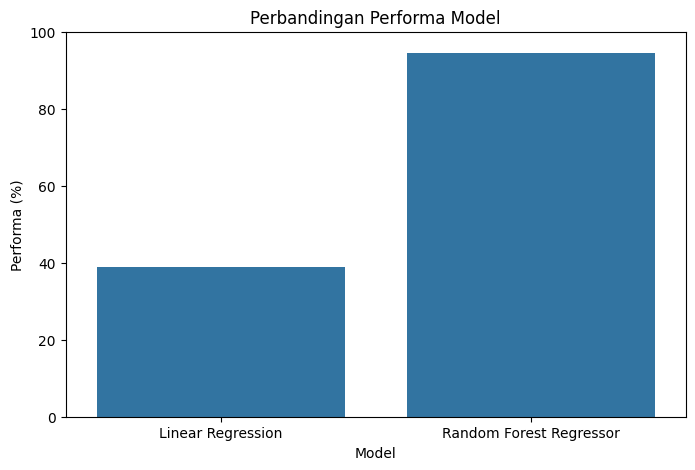

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Performa (%)"
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Performa (%)")
plt.ylim(0,100)

plt.show()

In [26]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

comparison.head(10)

,Actual,Predicted
0,425,376.788889
1,88,96.710370
2,4,11.220000
3,526,535.225278
4,13,14.920000
5,32,39.376667
6,706,748.628423
7,26,36.180000
8,2,9.697143
9,21,26.015897


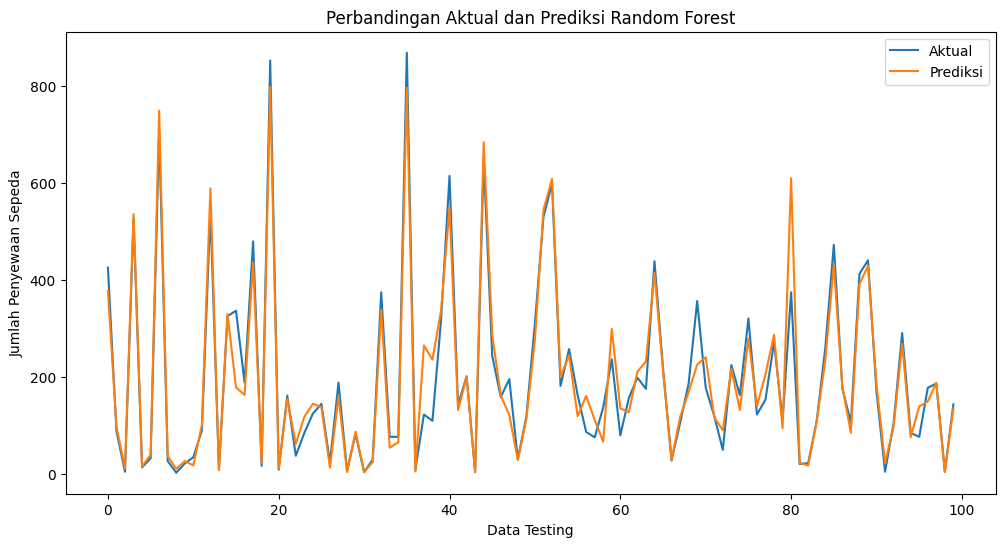

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    comparison["Actual"].values[:100],
    label="Aktual"
)

plt.plot(
    comparison["Predicted"].values[:100],
    label="Prediksi"
)

plt.title("Perbandingan Aktual dan Prediksi Random Forest")
plt.xlabel("Data Testing")
plt.ylabel("Jumlah Penyewaan Sepeda")

plt.legend()
plt.show()

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,hr,0.612967
8,temp,0.118782
1,yr,0.080854
6,workingday,0.057810
10,hum,0.026360
0,season,0.021948
9,atemp,0.021516
7,weathersit,0.018083
2,mnth,0.016319
5,weekday,0.012513


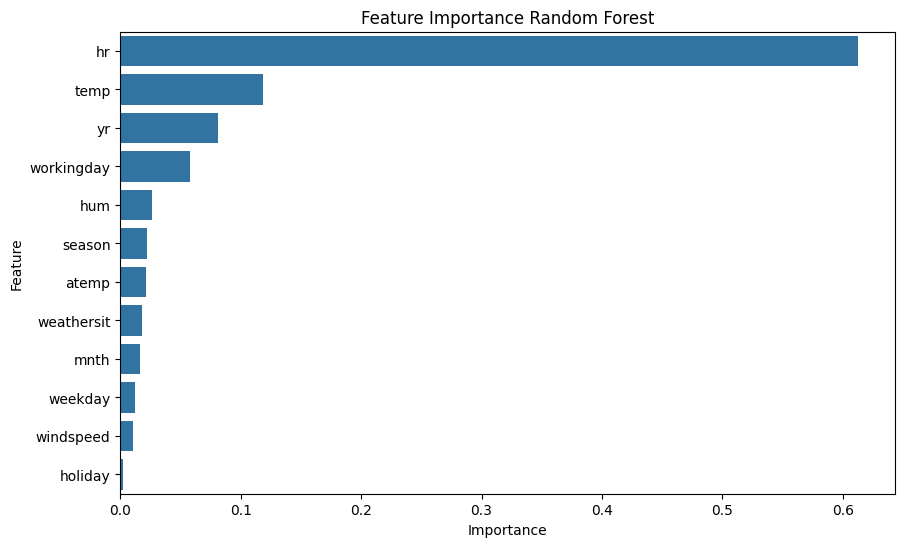

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Random Forest")
plt.show()

## 5.2 Interpretasi Hasil Evaluasi

Berdasarkan hasil evaluasi, Random Forest Regressor menghasilkan performa terbaik dibandingkan Linear Regression.

Model Random Forest Regressor memperoleh nilai R² Score sebesar 0,9447 atau setara dengan 94,47%. Nilai tersebut menunjukkan bahwa model mampu menjelaskan sekitar 94,47% variasi data jumlah penyewaan sepeda pada dataset.

Karena nilai performa model berada di atas batas minimal 80%, maka model telah memenuhi kriteria keberhasilan evaluasi yang ditetapkan.

Oleh karena itu, Random Forest Regressor dipilih sebagai model terbaik untuk digunakan dalam proses forecasting jumlah penyewaan sepeda.

## 5.3 Kesimpulan Evaluation

Tahap Evaluation menunjukkan bahwa model Random Forest Regressor memiliki performa terbaik dengan nilai R² Score sebesar 94,47%. Hasil ini menunjukkan bahwa model telah memenuhi kriteria sukses evaluasi minimal 80% dan layak digunakan sebagai model akhir dalam project forecasting.

# 6. Deployment

Tahap Deployment merupakan tahap akhir dalam framework CRISP-DM. Pada tahap ini, hasil akhir project akan dipublikasikan dalam bentuk website portfolio digital menggunakan Google Sites.

Website portfolio berisi:
1. Judul project
2. Identitas mahasiswa
3. Deskripsi studi kasus
4. Dataset dan sumber dataset
5. Tahapan CRISP-DM
6. Visualisasi hasil analisis
7. Screenshot coding
8. Hasil evaluasi model
9. Kesimpulan project

Selain itu, file project juga akan diunggah ke GitHub yang berisi:
- File notebook `.ipynb`
- Dataset `hour.csv`
- File `README.md`
- Link Google Sites
- Link YouTube presentasi

# 7. Kesimpulan

Project forecasting ini menggunakan Bike Sharing Dataset yang terdiri dari 17.379 data dan telah memenuhi ketentuan minimal 5.000 data. Analisis dilakukan menggunakan framework CRISP-DM mulai dari Business Understanding hingga Deployment.

Berdasarkan hasil evaluasi, Random Forest Regressor menjadi model terbaik dengan nilai R² Score sebesar 0,9447 atau 94,47%, sehingga telah memenuhi kriteria keberhasilan evaluasi di atas 80%.

Oleh karena itu, model Random Forest Regressor dipilih untuk melakukan forecasting jumlah penyewaan sepeda.